# This notebook is for generating all the scores

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
metrics  = pd.read_csv('metrics_results/mar1_full_results.csv')
ridership_by_date = pd.read_csv('metrics_results/ridership_results.csv')

In [7]:
metrics['bus_trust_score'] = (
    0.45 * metrics['p_otp'] +
    0.25 * metrics['p_severity'] +
    0.20 * metrics['p_reliability'] +
    0.10 * metrics['p_ghost']
)

In [8]:
metrics = metrics[['route_id', 'bus_trust_score']].sort_values(by='bus_trust_score')

In [9]:
ridership_by_date['ridership_score'] = (ridership_by_date.rides - ridership_by_date.rides.min()) / (ridership_by_date.rides.max() - ridership_by_date.rides.min())

In [10]:
metrics = metrics.merge(ridership_by_date, right_on='route', left_on='route_id', how='left')

In [11]:
metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   route_id         123 non-null    object 
 1   bus_trust_score  123 non-null    float64
 2   Unnamed: 0       123 non-null    int64  
 3   route            123 non-null    object 
 4   rides            123 non-null    float64
 5   ridership_score  123 non-null    float64
 6   log_ridership    123 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 6.9+ KB


In [12]:
metrics.head()

,route_id,bus_trust_score,Unnamed: 0,route,rides,ridership_score,log_ridership
0,171,53.913833,36,171,602.758007,0.032795,6.403173
1,N5,54.748333,125,N5,111.350746,0.000803,4.721626
2,62,55.138167,84,62,6658.338323,0.427034,8.803775
3,201,65.856833,43,201,1139.989324,0.067771,7.039651
4,169,66.521667,35,169,99.014493,0.000000,4.605315


(array([ 3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  3.,  2.,  1.,
         7.,  3.,  4.,  8., 10., 14., 14., 12., 10.,  6., 12.,  4.,  2.,
         4.,  2.,  0.,  1.]),
 array([53.91383333, 55.17207778, 56.43032222, 57.68856667, 58.94681111,
        60.20505556, 61.4633    , 62.72154444, 63.97978889, 65.23803333,
        66.49627778, 67.75452222, 69.01276667, 70.27101111, 71.52925556,
        72.7875    , 74.04574444, 75.30398889, 76.56223333, 77.82047778,
        79.07872222, 80.33696667, 81.59521111, 82.85345556, 84.1117    ,
        85.36994444, 86.62818889, 87.88643333, 89.14467778, 90.40292222,
        91.66116667]),
 <BarContainer object of 30 artists>)

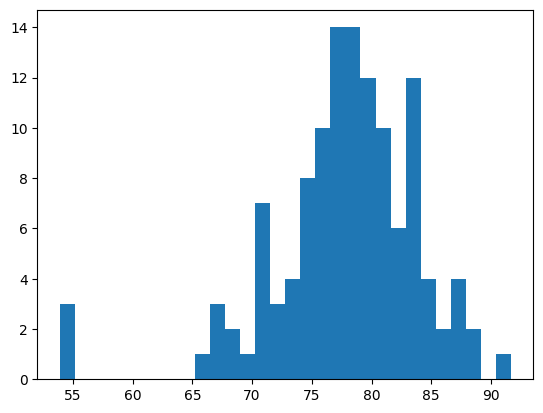

In [14]:
plt.hist(metrics['bus_trust_score'], bins=30)

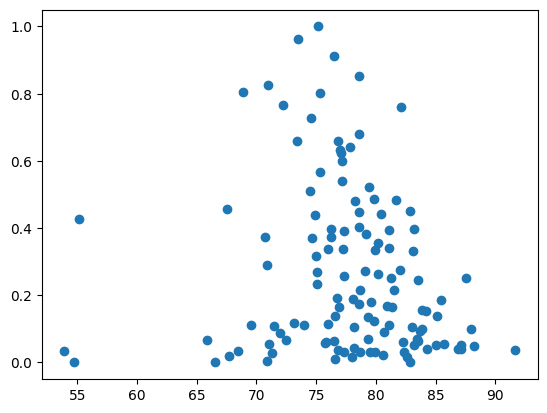

In [16]:
plt.scatter(y=metrics.ridership_score, x=metrics.bus_trust_score)

In [19]:
metrics.sort_values(by='rides', ascending=False)

,route_id,bus_trust_score,Unnamed: 0,route,rides,ridership_score,log_ridership
31,66,75.190000,89,66,15459.200599,1.000000,9.646024
22,9,73.512000,115,9,14870.736527,0.961689,9.607218
40,8,76.466667,103,8,14086.766467,0.910650,9.553062
66,79,78.608333,102,79,13211.742515,0.853683,9.488937
13,53,71.007833,71,53,12793.410180,0.826448,9.456764
...,...,...,...,...,...,...,...
43,111A,76.612500,9,111A,277.305389,0.011607,5.628719
11,165,70.876667,34,165,155.596567,0.003684,5.053673
98,55A,82.863000,77,55A,140.729614,0.002716,4.953921
1,N5,54.748333,125,N5,111.350746,0.000803,4.721626
